In [26]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('sci.mplstyle')

In [27]:
def RK4(a, b, N, alpha, phuongtrinh):
    h = (b - a) / N                  # tinh kich thuoc buoc thoi gian
    x = np.linspace(a, b, N + 1)     # tao mang thoi gian tu a den b gom N+1 diem
    y = np.zeros((N + 1, len(alpha)))# tao mang nghiem cho he ODE
    y[0] = alpha                     # gan dieu kien dau

    for i in range(N):               # lap qua tung buoc thoi gian
        k1 = phuongtrinh(x[i], y[i]) # dao ham tai dau buoc
        k2 = phuongtrinh(x[i] + h/2, y[i] + h*k1/2) # dao ham tai diem giua dung k1
        k3 = phuongtrinh(x[i] + h/2, y[i] + h*k2/2) # dao ham tai diem giua dung k2
        k4 = phuongtrinh(x[i] + h, y[i] + h*k3)     # dao ham tai cuoi buoc

        y[i+1] = y[i] + h*(k1 + 2*k2 + 2*k3 + k4)/6 # cap nhat nghiem RK4

    return x, y                      # tra ve mang thoi gian va nghiem

In [28]:
def dongdien(t, Y):
    I1 = Y[0]   # dong dien I1
    I2 = Y[1]   # dong dien I2

    dI1_dt = -4*I1 + 3*I2 + 6
    dI2_dt = -2.4*I1 + 1.6*I2 + 3.6

    F = np.array([dI1_dt, dI2_dt])
    return F

In [29]:
I1_0 = 0.0
I2_0 = 0.0
t_min = 0
t_max = 20
N_t = 1000

In [30]:
Y0_dongdien = np.array([I1_0, I2_0])

t, Y_dongdien = RK4(t_min, t_max, N_t, Y0_dongdien, dongdien)

I1 = Y_dongdien[:, 0]
I2 = Y_dongdien[:, 1]

In [31]:
def ghifile(t, Y_dongdien, filename="dongdien-RK4"):
    filename = f"KQ_{filename}.txt"

    with open(filename, "w", encoding="utf-8") as file:
        file.write("# Giai bai toan dong dien RK4\n")
        file.write("#\n")
        file.write(f"# {'t':>20s} {'I1':>20s} {'I2':>20s}\n")

        for t_step in range(len(t)):
            file.write(f"  {t[t_step]:20.8e} {Y_dongdien[t_step, 0]:20.8e} {Y_dongdien[t_step, 1]:20.8e}\n")

ghifile(t, Y_dongdien, filename="dongdien-RK4")

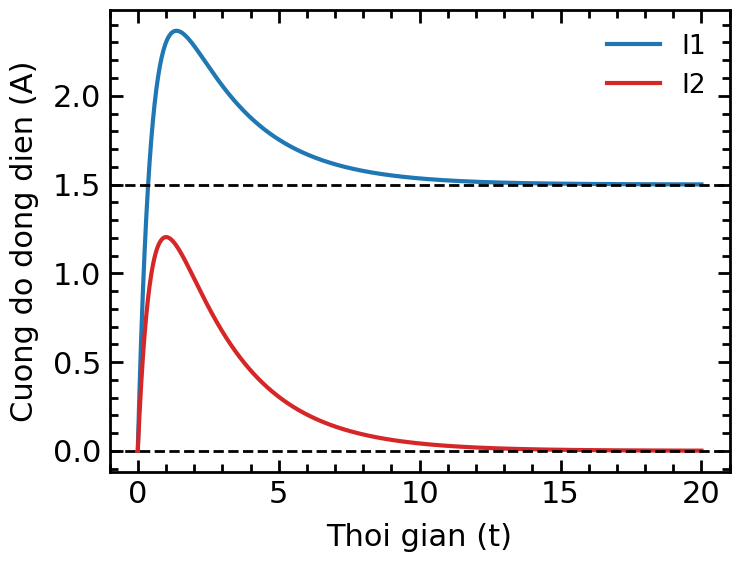

In [36]:
t_dongdien, I1_dongdien, I2_dongdien = np.loadtxt("KQ_dongdien-RK4.txt", comments="#", unpack=True)

plt.figure(figsize=(8,6))
plt.plot(t_dongdien, I1_dongdien, color="C0", lw = 3, label = "I1")
plt.plot(t_dongdien, I2_dongdien, color="C1", lw = 3, label = "I2")

plt.xlabel("Thoi gian (t)")
plt.ylabel("Cuong do dong dien (A)")
plt.legend()
plt.savefig("dongdien.png", dpi = 300)
plt.axhline(0, linestyle = "--",  c = 'black')
plt.axhline(1.5, linestyle = "--", c = 'black')

plt.show()